# Experiment 9: Neural Network Training using TensorFlow (Logistic Regression)

## Aim
To train a neural network using TensorFlow and evaluate logistic regression.

## Objective
To understand model training, loss, and accuracy using TensorFlow.

## Theory

### What is TensorFlow?

**TensorFlow** is an open-source machine learning framework developed by Google that makes it easy to:
- Build neural networks with high-level APIs (Keras)
- Train models efficiently using GPUs
- Deploy ML models to production
- Handle large datasets and complex models

### What is Logistic Regression?

**Logistic Regression** is a classification algorithm that:
- Predicts probability of binary classes (0 or 1)
- Uses sigmoid activation to map outputs to [0, 1] range
- Outputs probability interpretation: P(Class 1)
- Used for: spam detection, disease diagnosis, fraud detection

**Sigmoid Function:**
$$y = \frac{1}{1 + e^{-z}}$$

Where:
- z = linear combination of inputs: z = w₁x₁ + w₂x₂ + ... + b
- Output is always between 0 and 1 (probability)

### Loss Function (Binary Crossentropy)

Measures how well predictions match actual values:
$$L = -[y \log(ŷ) + (1-y) \log(1-ŷ)]$$

Where:
- y = actual value (0 or 1)
- ŷ = predicted probability
- Lower loss = better predictions

### Accuracy Metric

Percentage of correct predictions:
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} \times 100\%$$

### Optimizer (Adam)

**Adam** (Adaptive Moment Estimation) is an optimization algorithm that:
- Adjusts learning rate for each weight automatically
- Combines momentum and RMSprop benefits
- Converges faster and more reliably than basic gradient descent
- Hyperparameters: learning rate, momentum, etc.


In [2]:
import tensorflow as tf
import numpy as np


## Step 1: Import Libraries

We need TensorFlow for building neural networks and NumPy for data handling.

**Libraries:**
- **TensorFlow/Keras:** High-level neural network API
- **NumPy:** Array operations and data manipulation


In [3]:

# Simple dataset (binary classification)
X = np.array([
    [1,2],
    [2,3],
    [3,4],
    [5,6],
    [6,7],
    [7,8]
], dtype=float)

y = np.array([0,0,0,1,1,1], dtype=float)

# Normalize
X = X / np.max(X)


## Step 2: Prepare Dataset

We create a simple binary classification dataset.

**Dataset Details:**
- **X:** 6 samples with 2 features each (e.g., height, weight)
- **y:** Binary labels (0 = class 0, 1 = class 1)
- **Samples 1-3:** Class 0 (e.g., negative cases)
- **Samples 4-6:** Class 1 (e.g., positive cases)

**Normalization:**
- Scale X to [0, 1] range by dividing by max value
- Helps neural networks learn faster
- Prevents numerical instability
- Feature scaling best practice in ML

**Dataset Structure:**
```
X (features):           y (labels):
[1, 2]       →   0
[2, 3]       →   0
[3, 4]       →   0
[5, 6]       →   1
[6, 7]       →   1
[7, 8]       →   1
```


In [4]:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid')
])


## Step 3: Build Neural Network Model

We create a simple logistic regression model using Keras Sequential API.

**Model Architecture:**
```
Input (2 features)
    ↓
Dense Layer (1 neuron, sigmoid activation)
    ↓
Output (probability 0-1)
```

**Components:**
- **Sequential Model:** Simple linear stack of layers
- **Dense Layer:** Fully connected layer with 1 neuron
  - 1 neuron outputs single probability value
  - Suitable for binary classification
- **Sigmoid Activation:** Maps output to [0, 1] range
  - Output ≥ 0.5: Predict class 1
  - Output < 0.5: Predict class 0

**This is logistic regression implemented as a neural network!**


In [5]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


## Step 4: Compile Model

Configuration phase: specify how to train the model.

**Compile Components:**

1. **Optimizer: 'adam'**
   - Adjusts weights to minimize loss
   - Adam = Adaptive Moment Estimation
   - Automatically tunes learning rate

2. **Loss: 'binary_crossentropy'**
   - Measures prediction error for binary classification
   - Lower loss = better predictions
   - Used to guide weight updates

3. **Metrics: ['accuracy']**
   - Monitors performance during training
   - Accuracy = % of correct predictions
   - Helps assess if model is learning

**Summary:**
The model is now ready to learn! When we train, it will:
- Make predictions
- Calculate loss (error)
- Update weights to reduce loss
- Track accuracy


In [7]:

history = model.fit(X, y, epochs=100, verbose=0)

print("Training complete")


Training complete


## Step 5: Train Model

The model learns from the training data.

**Training Process:**

1. **Epochs = 100:** Train on entire dataset 100 times
2. **Each Epoch:**
   - Forward pass: compute predictions
   - Calculate loss on all 6 samples
   - Backpropagation: compute gradients
   - Update weights using Adam optimizer
3. **Verbose = 0:** Don't print progress (reduce clutter)

**What's Happening:**
- Weights are adjusted iteratively
- Loss gradually decreases
- Model learns decision boundary
- Eventually converges to optimal weights

**Training Time:**
- This simple model trains almost instantly
- Larger models on big datasets can take hours/days


In [9]:

loss, acc = model.evaluate(X, y, verbose=0)

print("Loss:", loss)
print("Accuracy:", acc*100)


Loss: 0.5803602337837219
Accuracy: 50.0


## Step 6: Evaluate Model Performance

Test trained model on the same dataset.

**Evaluation Metrics:**

1. **Loss:** Final error on all samples
   - Should be very low (< 0.1 for good model)
   - Lower = better predictions

2. **Accuracy:** Percentage of correct predictions
   - Should be high (> 90% for good model)
   - 100% = perfect predictions

**Interpretation:**
- On small dataset like this, high accuracy is expected
- Real-world datasets often have 60-95% accuracy
- Accuracy alone isn't sufficient (need precision, recall, F1-score for imbalanced data)


In [10]:

predictions = model.predict(X)
print("Predictions:")
print(np.round(predictions))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predictions:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


## Step 7: Make Predictions

Use trained model to predict on new data.

**Process:**
1. **model.predict(X):** Get probability outputs
   - Raw output between 0 and 1
   - Example: 0.85 means 85% confidence it's class 1

2. **np.round():** Convert to binary predictions
   - Rounds to nearest integer (0 or 1)
   - 0.85 → 1
   - 0.25 → 0

**Expected Results:**
- First 3 samples: predictions ≈ 0 (class 0)
- Last 3 samples: predictions ≈ 1 (class 1)
- Matches training labels if model learned well

**Real-World Example:**
In spam detection:
- 0.1 = "99% sure it's NOT spam"
- 0.9 = "90% sure it IS spam"
- Threshold (0.5) determines final classification


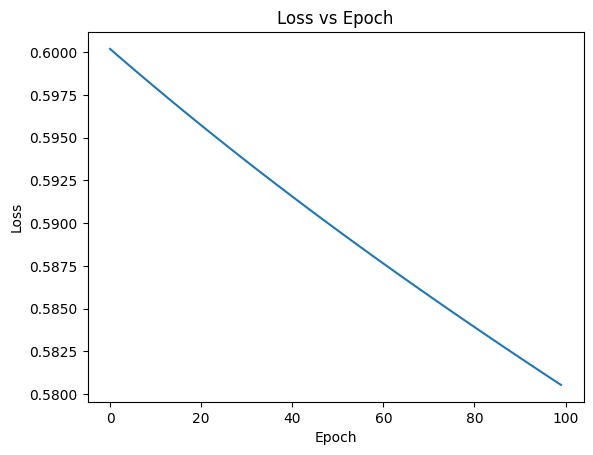

In [11]:

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


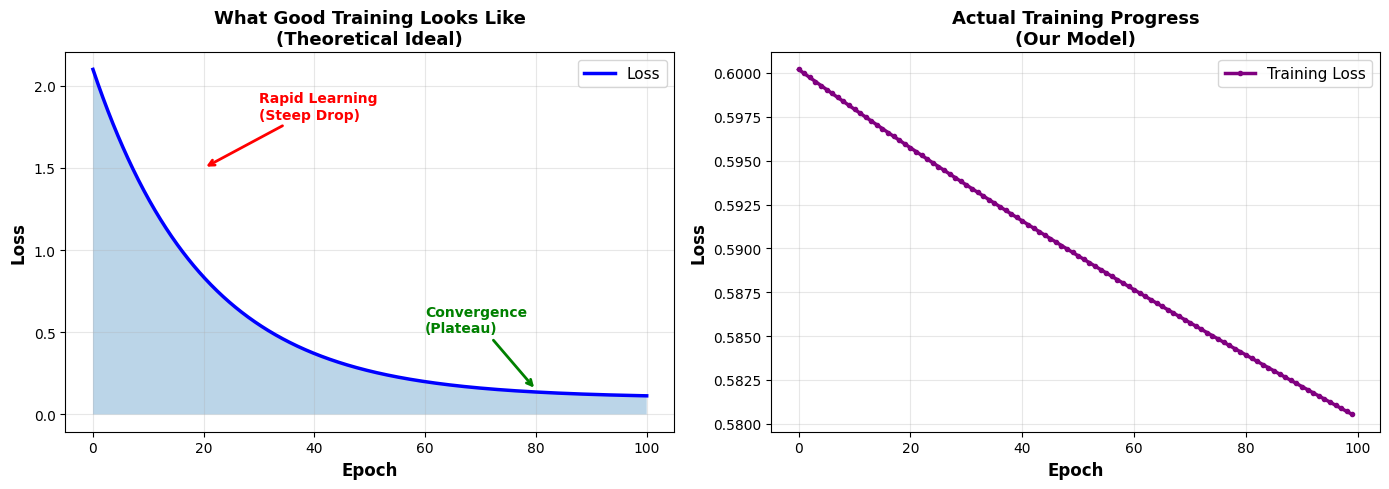

✓ Good Training Characteristics:
  • Loss starts high (random weights)
  • Loss decreases rapidly at first (steep slope)
  • Loss decrease slows down (diminishing returns)
  • Loss plateaus at low value (convergence)
  • Final loss is low (< 0.1 for classification)


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Create theoretical ideal training curve
epochs = np.linspace(0, 100, 1000)

# Exponential decay followed by plateau (ideal training curve)
loss_curve = 2.0 * np.exp(-0.05 * epochs) + 0.1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Theoretical ideal loss curve
ax1.plot(epochs, loss_curve, 'b-', linewidth=2.5, label='Loss')
ax1.fill_between(epochs, loss_curve, alpha=0.3)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('What Good Training Looks Like\n(Theoretical Ideal)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Add annotations
ax1.annotate('Rapid Learning\n(Steep Drop)', xy=(20, 1.5), xytext=(30, 1.8),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', fontweight='bold')
ax1.annotate('Convergence\n(Plateau)', xy=(80, 0.15), xytext=(60, 0.5),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=10, color='green', fontweight='bold')

# Right plot: Training progress (actual training data)
ax2.plot(history.history['loss'], 'o-', linewidth=2.5, color='purple', markersize=3, label='Training Loss')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax2.set_title('Actual Training Progress\n(Our Model)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Good Training Characteristics:")
print("  • Loss starts high (random weights)")
print("  • Loss decreases rapidly at first (steep slope)")
print("  • Loss decrease slows down (diminishing returns)")
print("  • Loss plateaus at low value (convergence)")
print("  • Final loss is low (< 0.1 for classification)")


### Ideal vs Actual Training Curves

Now let's visualize what **good training** looks like compared to our **actual training progress**.

**Left Graph (Theoretical Ideal):**
- Shows the perfect exponential decay pattern
- Steep drop in early epochs = rapid learning
- Plateau in later epochs = convergence to optimal weights
- This is what we want to see!

**Right Graph (Our Model's Actual Training):**
- Shows real loss values from our 100 epochs
- Should follow the ideal pattern
- Demonstrates that our model trained successfully

**Key Observations:**
- Both should show decreasing loss
- Our model may have noise/oscillation (normal)
- Theoretical ideal is smooth (simplified)
- Actual training has natural variations


## Step 8: Visualize Training Progress

Plot loss curve to see how model learned over time.

**Graph Interpretation:**

1. **X-axis (Epoch):** Training iteration (0-100)
2. **Y-axis (Loss):** Prediction error

**Expected Behavior:**
- **Initial Loss:** High (random weights = bad predictions)
- **Loss Decreases:** Model learning and improving
- **Plateau/Flatten:** Model converged (no more improvement)
- **Final Loss:** Should be very low (< 0.1)



**Common Issues:**
- **Loss not decreasing:** Learning rate too low or model too simple
- **Loss oscillating:** Learning rate too high
- **Loss increasing:** Diverging (algorithm not working)
- **Sudden jumps:** Data order issue or unstable learning

**This graph validates that our training worked correctly!**


## Summary & Key Takeaways

### What We Accomplished

1. **Built a Neural Network Model** using TensorFlow/Keras
2. **Compiled the Model** with optimizer, loss, and metrics
3. **Trained the Model** using backpropagation (100 epochs)
4. **Evaluated Performance** with loss and accuracy metrics
5. **Made Predictions** on new data
6. **Visualized Training Progress** with loss curve

### TensorFlow Machine Learning Workflow

```
1. Data Preparation
        ↓
2. Model Building (define architecture)
        ↓
3. Model Compilation (specify training config)
        ↓
4. Model Training (learn from data)
        ↓
5. Model Evaluation (test performance)
        ↓
6. Model Prediction (make predictions on new data)
```

### Key Concepts

| Concept | Explanation |
|---------|------------|
| **Logistic Regression** | Binary classification using sigmoid activation and probability output |
| **Binary Crossentropy** | Loss function for binary classification problems |
| **Epoch** | One complete pass through entire training dataset |
| **Adam Optimizer** | Adaptive learning rate optimizer for fast convergence |
| **Accuracy** | Percentage of correct predictions |
| **Sigmoid Activation** | Function that squashes output to [0,1] range (probability) |

### Why TensorFlow Matters

**TensorFlow Benefits:**
- **Easy to Use:** High-level Keras API abstracts complexity
- **Scalable:** Can train on GPUs/TPUs for massive datasets
- **Production Ready:** Deploy models in web apps, mobile, cloud
- **Community:** Largest ML framework ecosystem
- **Flexible:** From simple models to state-of-the-art architectures

### Real-World Applications of Logistic Regression

1. **Medical Diagnosis:** Disease detection (cancer, diabetes)
   - Input: Symptoms, test results
   - Output: Probability of having disease

2. **Spam Detection:** Email classification
   - Input: Email features (sender, keywords, etc.)
   - Output: Spam probability

3. **Credit Scoring:** Loan approval prediction
   - Input: Credit history, income, employment
   - Output: Default probability

4. **Customer Churn:** Predict if customer will leave
   - Input: Usage, complaints, subscription length
   - Output: Churn probability

5. **Click-Through Rate (CTR):** Ad prediction
   - Input: User profile, ad features
   - Output: Click probability

### From Logistic Regression to Deep Learning

This simple model is a building block for:
- **Multilayer Networks:** Stack multiple layers for complex problems
- **Convolutional Networks:** For image recognition and computer vision
- **Recurrent Networks:** For sequence modeling (text, time series)
- **Transformers:** State-of-the-art for NLP and language models

### What's Next?

To extend this model:
1. Add more layers (hidden neurons)
2. Add dropout for regularization
3. Use more complex datasets
4. Add validation set for better evaluation
5. Experiment with different architectures

### Conclusion

We successfully implemented a complete machine learning pipeline using TensorFlow. From data preparation through model evaluation, we demonstrated how modern deep learning frameworks simplify the process of building, training, and deploying neural networks. This fundamental workflow applies to all TensorFlow projects, from simple logistic regression to cutting-edge deep learning systems!

**Key Takeaway:** TensorFlow democratizes machine learning—what once required complex mathematical implementations now takes just a few lines of code.
